# This notebook contains more advanced examples

In [1]:
from __future__ import division, absolute_import, print_function
%matplotlib inline

import lmfit
import matplotlib.pyplot as plt
import numpy as np

from resonator import background, reflection, see

In [2]:
# Make some fake data to use for the example fits
f_r = 1e9
frequency = np.linspace(f_r - 1e6, f_r + 1e6, 501)
bg = background.MagnitudePhase().func(frequency=frequency, magnitude=0.01, phase=np.pi / 3)
fg = reflection.LinearReflection().func(frequency=frequency, resonance_frequency=f_r, internal_loss=1e-5, coupling_loss=5e-5)
data = bg * fg + 0.0002 * (np.random.randn(frequency.size) + 1j * np.random.randn(frequency.size))

## Use initial params to improve on the guessing function

The default algorithm used by `lmfit` is Levenberg-Marquardt, which is fast but finds only the local minimum of the residual function given by the initial values. The most common reason for a fit to fail is that the `guess` function provides initial values that are in a local minimum that is not the global minimum. If a data set that looks "reasonable" fails to converge to the correct values, a quick fix is to try different initial values. If best-fit parameters from a previous successful fit are available and the data to be fit is similar, this same technique can be used to accelerate the fit or achieve convergence.

[[Model]]
    (Model(magnitude_phase_delay) * Model(linear_reflection))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 29
    # data points      = 1002
    # variables        = 6
    chi-square         = 3.9868e-05
    reduced chi-square = 4.0028e-08
    Akaike info crit   = -17061.7640
    Bayesian info crit = -17032.3055
    R-squared          = np.complex128(0.998670151617596-0.003907266239991372j)
[[Variables]]
    frequency_reference:  1e+09 (fixed)
    magnitude:            0.00998697 +/- 9.3746e-06 (0.09%) (init = 0.009962319)
    phase:                1.04569161 +/- 9.3725e-04 (0.09%) (init = 1.034575)
    delay:                4.0246e-11 +/- 2.6077e-10 (647.93%) (init = 2.071652e-08)
    resonance_frequency:  1.0000e+09 +/- 108.637349 (0.00%) (init = 9.99994e+08)
    coupling_loss:        5.0058e-05 +/- 1.8927e-07 (0.38%) (init = 5.408333e-05)
    internal_loss:        1.0004e-05 +/- 2.2103e-07 (2.21%) (init = 1e-09)
[[Correlations]] (unreported c

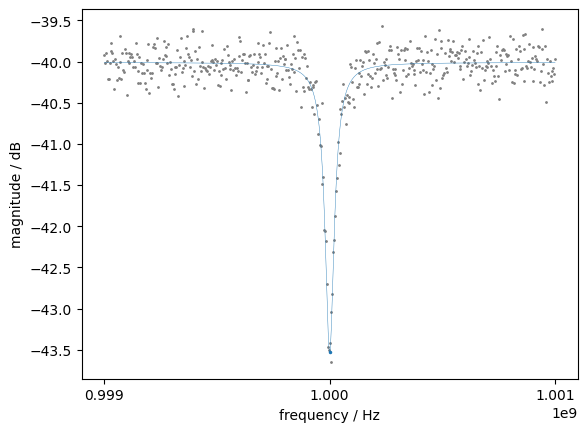

In [8]:
params = lmfit.Parameters()
params.add(name='internal_loss', value=1e-9) 
r = reflection.LinearReflectionFitter(frequency=frequency, data=data, params=params, background_model=background.MagnitudePhaseDelay())
fig, ax = see.magnitude_vs_frequency(resonator=r)
print(r.result.fit_report())

## Use initial parameters to control whether or not to vary a parameter in the fit

For example, the value of the coupling can be fixed to a value from a simulation. 

[[Model]]
    (Model(magnitude_phase) * Model(linear_reflection))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 21
    # data points      = 1002
    # variables        = 4
    chi-square         = 3.9875e-05
    reduced chi-square = 3.9955e-08
    Akaike info crit   = -17065.5969
    Bayesian info crit = -17045.9579
    R-squared          = np.complex128(0.9987295386091706-0.0038831253640607376j)
[[Variables]]
    magnitude:            0.00998681 +/- 9.3512e-06 (0.09%) (init = 0.009935738)
    phase:                1.04569168 +/- 9.3635e-04 (0.09%) (init = 1.093573)
    resonance_frequency:  1.0000e+09 +/- 108.463550 (0.00%) (init = 9.99994e+08)
    coupling_loss:        5e-05 (fixed)
    internal_loss:        9.9910e-06 +/- 2.1681e-07 (2.17%) (init = 1.38494e-05)
[[Correlations]] (unreported correlations are < 0.100)
    C(magnitude, internal_loss)   = +0.2531
    C(phase, resonance_frequency) = -0.2530


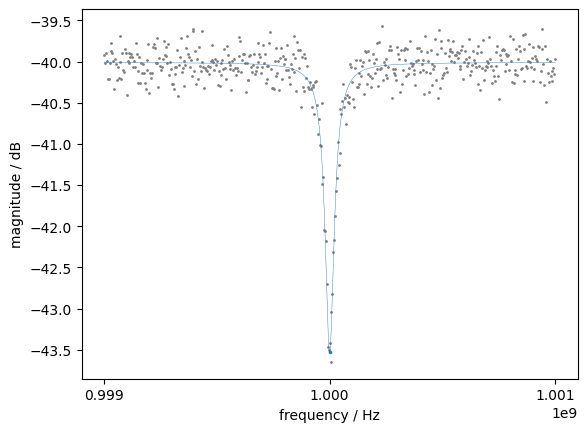

In [7]:
params = lmfit.Parameters()
params.add(name='coupling_loss', value=5e-5, vary=False)
r = reflection.LinearReflectionFitter(frequency=frequency, data=data, params=params)
fig, ax = see.magnitude_vs_frequency(resonator=r)
print(r.result.fit_report())  # Note that coupling_loss is now fixed